# EmosiKu: Klasifikasi Indikasi Gangguan Kesehatan Mental pada Teks Media Sosial Berbahasa Indonesia Menggunakan Model IndoBERT

**Sistem:** Deteksi Depresi dan Kecemasan berbasis NLP (Text Classification)
**Model Utama:** IndoBERT


---


Anggota Kelompok
1. Erlin Sari Ramadhani   (2315061056)
2. Aulia Rahmi Shakira    (2315061104)
3. Nadjwa Tasya Safira    (2315061024)

In [1]:
!pip install transformers datasets Sastrawi scikit-learn pandas numpy torch imbalanced-learn seaborn matplotlib -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.5 MB/s eta 0:00:00


## 1. Import Library & Koneksi Google Drive

In [2]:
import pandas as pd
import numpy as np
import re
import torch
import os
from google.colab import drive
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

drive.mount('/content/drive')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# ══════════════════════════════════════════════════════════
# Fungsi Metrik — didefinisikan di sini agar tersedia
# untuk Baseline maupun Final Model
# ══════════════════════════════════════════════════════════
def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )
    _, _, f1_per_class, _ = precision_recall_fscore_support(
        labels, preds, average=None, zero_division=0
    )
    acc = accuracy_score(labels, preds)
    return {
        'accuracy'        : acc,
        'f1_macro'        : f1,
        'precision_macro' : precision,
        'recall_macro'    : recall,
        'f1_non_depresi'  : f1_per_class[0],
        'f1_depresi'      : f1_per_class[1],
    }


# ══════════════════════════════════════════════════════════
# OverfittingStopCallback — didefinisikan global agar
# bisa dipakai baseline maupun final model
# ══════════════════════════════════════════════════════════
from torch.nn import CrossEntropyLoss
from transformers import TrainerCallback

class OverfittingStopCallback(TrainerCallback):
    def __init__(self, loss_gap_threshold=0.15, patience=2):
        self.threshold       = loss_gap_threshold
        self.patience        = patience
        self._bad_epochs     = 0
        self._train_loss_epoch = {}

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and 'loss' in logs and 'eval_loss' not in logs:
            ep = int(state.epoch) + 1 if state.epoch else 1
            self._train_loss_epoch.setdefault(ep, []).append(logs['loss'])

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics is None:
            return
        eval_loss       = metrics.get('eval_loss', None)
        cur_epoch       = int(round(metrics.get('epoch', state.epoch or 0)))
        train_losses_ep = self._train_loss_epoch.get(cur_epoch, [])
        if eval_loss is None or not train_losses_ep:
            return
        avg_train_loss = sum(train_losses_ep) / len(train_losses_ep)
        gap = eval_loss - avg_train_loss
        print(f'\n[OverfittingCallback] Epoch {cur_epoch} | '
              f'Train Loss: {avg_train_loss:.4f} | Eval Loss: {eval_loss:.4f} | Gap: {gap:+.4f}')
        if gap > self.threshold:
            self._bad_epochs += 1
            print(f'  ⚠️  Gap melebihi threshold! ({self._bad_epochs}/{self.patience})')
            if self._bad_epochs >= self.patience:
                print(f'  🛑 OVERFITTING TERDETEKSI — Training dihentikan!')
                control.should_training_stop = True
        else:
            if self._bad_epochs > 0:
                print('  ✅ Gap kembali normal — counter reset.')
            self._bad_epochs = 0

print('✅ compute_metrics & OverfittingStopCallback siap digunakan.')


Mounted at /content/drive
✅ compute_metrics & OverfittingStopCallback siap digunakan.


## 2. Load Dataset dari Google Drive
Dataset yang digunakan adalah "Depression and Anxiety in Twitter (ID)" oleh Steven Hans.

**Dataset Link:** https://www.kaggle.com/datasets/stevenhans/depression-and-anxiety-in-twitter-id

In [3]:
path_folder = '/content/drive/MyDrive/EmosiKu/DATASET/'

try:
    train_df = pd.read_csv(os.path.join(path_folder, 'datd_train.csv'))
    test_df  = pd.read_csv(os.path.join(path_folder, 'datd_test.csv'))
    print('Dataset berhasil dimuat!')
    display(train_df.head())
except Exception as e:
    print(f'Error memuat dataset: {e}')

# ── Cek distribusi kelas SEBELUM balancing ──
print('\n=== Distribusi Kelas TRAIN (SEBELUM) ===')
print(train_df['label'].value_counts())
print(f"Rasio imbalance: {train_df['label'].value_counts()[0] / train_df['label'].value_counts()[1]:.2f}x")


Dataset berhasil dimuat!


,text,label
0,"oh pantesan tadi pada rame, ternyata monek mau...",0
1,"Semakin bertambah usia, semakin cemas hidup.",0
2,gelisah bgt astaga,1
3,Udah jangan terlalu cemas sikapku tak berubah ...,0
4,Giliran Aldebaran diambang kematian...Semua ba...,0



=== Distribusi Kelas TRAIN (SEBELUM) ===
label
0    1468
1     733
Name: count, dtype: int64
Rasio imbalance: 2.00x


## 3. Preprocessing Data
1. Pembersihan teks dari URL, mention (@), hashtag (#), emoji, dan karakter khusus.
2. Normalisasi teks ke lowercase.
3. Stopword removal menggunakan Sastrawi.

In [4]:
factory_stopword = StopWordRemoverFactory()
stopword = factory_stopword.create_stop_word_remover()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    text = stopword.remove(text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

display(train_df[['text', 'clean_text', 'label']].head())

,text,clean_text,label
0,"oh pantesan tadi pada rame, ternyata monek mau...",pantesan tadi rame ternyata monek mau cb juni ...,0
1,"Semakin bertambah usia, semakin cemas hidup.",semakin bertambah usia semakin cemas hidup,0
2,gelisah bgt astaga,gelisah bgt astaga,1
3,Udah jangan terlalu cemas sikapku tak berubah ...,udah jangan terlalu cemas sikapku tak berubah ...,0
4,Giliran Aldebaran diambang kematian...Semua ba...,giliran aldebaran diambang kematiansemua baru ...,0


## 3b. Menangani Data Imbalanced
Strategi yang digunakan:
- **RandomOverSampler** → duplikat sampel Depresi hingga seimbang dengan Non-Depresi
- **Class Weight dari data ASLI** → bobot dihitung sebelum oversampling agar tetap mencerminkan ketidakseimbangan asli


In [5]:
from collections import Counter

# ── Class weight dihitung dari data ASLI (sebelum resample) ──
# Ini agar WeightedTrainer tetap efektif memberi penalti lebih ke kelas Depresi
class_weights_orig = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_df['label'].tolist()
)
class_weights_tensor = torch.tensor(class_weights_orig, dtype=torch.float)
print(f'Class Weights (dari data ASLI) → Non-Depresi: {class_weights_orig[0]:.4f} | Depresi: {class_weights_orig[1]:.4f}')

# ── Oversampling kelas minoritas (Depresi) ──
ros = RandomOverSampler(random_state=SEED)
train_texts_resampled, train_labels_resampled = ros.fit_resample(
    train_df[['clean_text']], train_df['label']
)
train_texts_resampled  = train_texts_resampled['clean_text'].tolist()
train_labels_resampled = train_labels_resampled.tolist()

print('\n=== Distribusi Kelas TRAIN ===')
print(f'Sebelum  : {dict(Counter(train_df["label"].tolist()))}')
print(f'Sesudah  : {dict(Counter(train_labels_resampled))}')


Class Weights (dari data ASLI) → Non-Depresi: 0.7497 | Depresi: 1.5014

=== Distribusi Kelas TRAIN ===
Sebelum  : {0: 1468, 1: 733}
Sesudah  : {0: 1468, 1: 1468}


## 4. Tokenisasi dengan IndoBERT
Tokenizer bawaan dari `indobenchmark/indobert-base-p1` untuk mengubah teks menjadi representasi token yang dapat diproses oleh model Transformer.

In [6]:
model_name = 'indobenchmark/indobert-base-p1'
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenize train (resampled) & test
train_encodings = tokenizer(
    train_texts_resampled,
    truncation=True, padding=True, max_length=128
)
test_encodings = tokenizer(
    test_df['clean_text'].tolist(),
    truncation=True, padding=True, max_length=128
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Membuat Dataset PyTorch Custom

In [7]:
class MentalHealthDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = MentalHealthDataset(train_encodings, train_labels_resampled)
test_dataset  = MentalHealthDataset(test_encodings, test_df['label'].tolist())

print(f'Train size (after resample): {len(train_dataset)}')
print(f'Test size : {len(test_dataset)}')


Train size (after resample): 2936
Test size : 550


---
## 5a. Baseline Model (Tanpa Penanganan Imbalanced)
Sebelum melatih model final, kita latih **baseline model** terlebih dahulu sebagai pembanding.

Baseline menggunakan:
- ❌ Tanpa oversampling → data train asli (imbalanced: Non-Depresi 1468 vs Depresi 733)
- ❌ Tanpa class weight → semua kelas diperlakukan sama
- ❌ Tanpa label smoothing
- ✅ `Trainer` bawaan HuggingFace
- ✅ Dropout & training arguments sama dengan model final (adil untuk perbandingan)


In [8]:
# ── Tokenisasi data ASLI (imbalanced, tanpa oversampling) ──
train_encodings_base = tokenizer(
    train_df['clean_text'].tolist(),
    truncation=True, padding=True, max_length=128
)
train_dataset_base = MentalHealthDataset(train_encodings_base, train_df['label'].tolist())

print('=== Dataset Baseline (Imbalanced) ===')
from collections import Counter
print(f'Train : {dict(Counter(train_df["label"].tolist()))}')
print(f'Test  : {dict(Counter(test_df["label"].tolist()))}')
print(f'Total train: {len(train_dataset_base)} | Total test: {len(test_dataset)}')


=== Dataset Baseline (Imbalanced) ===
Train : {0: 1468, 1: 733}
Test  : {1: 161, 0: 389}
Total train: 2201 | Total test: 550


In [9]:
# ── Baseline model (dropout sama, supaya perbandingan adil) ──
model_base = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.2,
)

training_args_base = TrainingArguments(
    output_dir='./EmosiKu_Baseline',
    num_train_epochs=6,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_ratio=0.15,
    weight_decay=0.05,
    logging_dir='./logs_base',
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    report_to='none',
    lr_scheduler_type='cosine',
    seed=SEED,
)

trainer_base = Trainer(
    model=model_base,
    args=training_args_base,
    train_dataset=train_dataset_base,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2),
        OverfittingStopCallback(loss_gap_threshold=0.15, patience=2),
    ],
)

print('✅ Baseline Trainer siap!')


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Baseline Trainer siap!


In [10]:
print('🚀 Training BASELINE MODEL (tanpa oversampling & class weight)...')
trainer_base.train()


🚀 Training BASELINE MODEL (tanpa oversampling & class weight)...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,F1 Non Depresi,F1 Depresi
1,0.529224,0.457415,0.794545,0.774226,0.765228,0.809250,0.841958,0.706494
2,0.343139,0.379033,0.843636,0.817541,0.808876,0.829392,0.886544,0.748538
3,0.355487,0.393556,0.850909,0.817264,0.822410,0.812691,0.895674,0.738854
4,0.237514,0.426242,0.850909,0.819972,0.819972,0.819972,0.894602,0.745342
5,0.186943,0.506054,0.843636,0.818122,0.808862,0.831212,0.886243,0.750000
6,0.136607,0.526414,0.841818,0.815714,0.806811,0.828107,0.885073,0.746356



[OverfittingCallback] Epoch 1 | Train Loss: 0.5816 | Eval Loss: 0.4574 | Gap: -0.1242


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[OverfittingCallback] Epoch 2 | Train Loss: 0.4608 | Eval Loss: 0.3790 | Gap: -0.0818


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[OverfittingCallback] Epoch 6 | Train Loss: 0.1804 | Eval Loss: 0.5264 | Gap: +0.3460
  ⚠️  Gap melebihi threshold! (2/2)
  🛑 OVERFITTING TERDETEKSI — Training dihentikan!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=828, training_loss=0.3479594743770102, metrics={'train_runtime': 283.6549, 'train_samples_per_second': 46.557, 'train_steps_per_second': 2.919, 'total_flos': 495408311693640.0, 'train_loss': 0.3479594743770102, 'epoch': 6.0})

In [11]:
# ── Evaluasi baseline di TEST SET ──
base_test_results  = trainer_base.evaluate(eval_dataset=test_dataset)
# ── Evaluasi baseline di TRAIN SET ──
base_train_results = trainer_base.evaluate(eval_dataset=train_dataset_base)

print('=' * 55)
print('  BASELINE — HASIL EVALUASI TEST SET')
print('=' * 55)
for k, v in base_test_results.items():
    label = k.replace('eval_', '').replace('_', ' ').title()
    print(f'  {label:<25}: {v:.4f}' if isinstance(v, float) else f'  {label:<25}: {v}')



[OverfittingCallback] Epoch 6 | Train Loss: 0.1804 | Eval Loss: 0.4265 | Gap: +0.2461
  ⚠️  Gap melebihi threshold! (3/2)
  🛑 OVERFITTING TERDETEKSI — Training dihentikan!

[OverfittingCallback] Epoch 6 | Train Loss: 0.1804 | Eval Loss: 0.1680 | Gap: -0.0124
  ✅ Gap kembali normal — counter reset.
  BASELINE — HASIL EVALUASI TEST SET
  Loss                     : 0.4265
  Accuracy                 : 0.8509
  F1 Macro                 : 0.8200
  Precision Macro          : 0.8200
  Recall Macro             : 0.8200
  F1 Non Depresi           : 0.8946
  F1 Depresi               : 0.7453
  Runtime                  : 1.9250
  Samples Per Second       : 285.7100
  Steps Per Second         : 4.6750
  Epoch                    : 6.0000


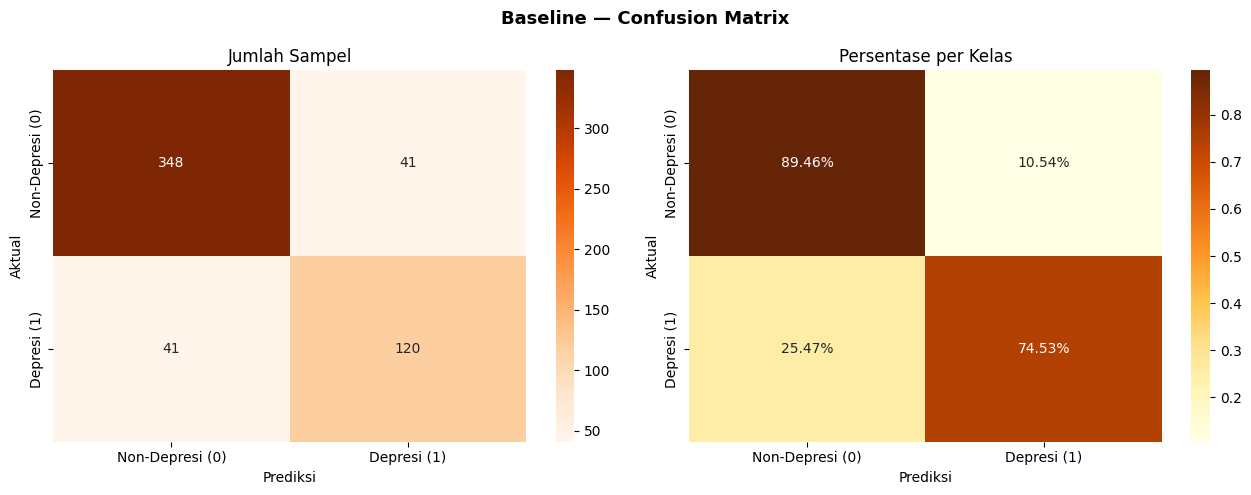


  BASELINE — CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Non-Depresi (0)     0.8946    0.8946    0.8946       389
    Depresi (1)     0.7453    0.7453    0.7453       161

       accuracy                         0.8509       550
      macro avg     0.8200    0.8200    0.8200       550
   weighted avg     0.8509    0.8509    0.8509       550

Recall Non-Depresi : 0.8946 (89.46%)
Recall Depresi     : 0.7453 (74.53%)


In [12]:
base_pred = trainer_base.predict(test_dataset)
y_pred_base = np.argmax(base_pred.predictions, axis=1)
y_true_base = base_pred.label_ids

cm_base     = confusion_matrix(y_true_base, y_pred_base)
cm_base_norm = cm_base.astype('float') / cm_base.sum(axis=1)[:, np.newaxis]
class_names = ['Non-Depresi (0)', 'Depresi (1)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Baseline — Confusion Matrix', fontsize=13, fontweight='bold')
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Jumlah Sampel'); axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')
sns.heatmap(cm_base_norm, annot=True, fmt='.2%', cmap='YlOrBr',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Persentase per Kelas'); axes[1].set_xlabel('Prediksi'); axes[1].set_ylabel('Aktual')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EmosiKu_Model/confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*55)
print('  BASELINE — CLASSIFICATION REPORT')
print('='*55)
print(classification_report(y_true_base, y_pred_base, target_names=class_names, digits=4))

tn_b, fp_b, fn_b, tp_b = cm_base.ravel()
print(f'Recall Non-Depresi : {tn_b/(tn_b+fp_b):.4f} ({tn_b/(tn_b+fp_b)*100:.2f}%)')
print(f'Recall Depresi     : {tp_b/(tp_b+fn_b):.4f} ({tp_b/(tp_b+fn_b)*100:.2f}%)')


---
## 5b. Final Model (Dengan Oversampling + Class Weight)
Setelah baseline dilatih, kini model final dilatih dengan semua perbaikan:
- ✅ RandomOverSampler → data train seimbang (1468 vs 1468)
- ✅ Class weight dari data asli → WeightedTrainer
- ✅ Label smoothing 0.1
- ✅ OverfittingStopCallback + EarlyStoppingCallback


In [13]:
# ── Load model final dengan dropout lebih tinggi ──
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.2,
)

# ── Custom Trainer dengan class-weighted loss ──
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        weights = class_weights_tensor.to(logits.device)
        loss_fn = CrossEntropyLoss(weight=weights, label_smoothing=0.1)
        loss    = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# ── Training Arguments ──
training_args = TrainingArguments(
    output_dir='./EmosiKu_Model',
    num_train_epochs=6,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    warmup_ratio=0.15,
    weight_decay=0.05,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    report_to='none',
    lr_scheduler_type='cosine',
    seed=SEED,
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[
        EarlyStoppingCallback(early_stopping_patience=2),
        OverfittingStopCallback(loss_gap_threshold=0.15, patience=2),
    ],
)

print('✅ Final Model & Trainer siap!')
print('   Callback: EarlyStoppingCallback (patience=2) + OverfittingStopCallback (gap>0.15)')


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ Final Model & Trainer siap!
   Callback: EarlyStoppingCallback (patience=2) + OverfittingStopCallback (gap>0.15)


## 6. Training & Evaluasi Model Final


In [14]:
print('🚀 Training FINAL MODEL (dengan oversampling + class weight)...')
trainer.train()


🚀 Training FINAL MODEL (dengan oversampling + class weight)...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,F1 Non Depresi,F1 Depresi
1,0.460124,0.641570,0.670909,0.667078,0.721212,0.756431,0.702791,0.631365
2,0.402539,0.529675,0.785455,0.769665,0.766009,0.817385,0.829971,0.709360
3,0.395148,0.537314,0.789091,0.769055,0.760860,0.805394,0.837079,0.701031
4,0.401645,0.564279,0.803636,0.784982,0.775862,0.822957,0.848315,0.721649



[OverfittingCallback] Epoch 1 | Train Loss: 0.5746 | Eval Loss: 0.6416 | Gap: +0.0670


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[OverfittingCallback] Epoch 2 | Train Loss: 0.4665 | Eval Loss: 0.5297 | Gap: +0.0632


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[OverfittingCallback] Epoch 4 | Train Loss: 0.3193 | Eval Loss: 0.5643 | Gap: +0.2449
  ⚠️  Gap melebihi threshold! (2/2)
  🛑 OVERFITTING TERDETEKSI — Training dihentikan!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=736, training_loss=0.43324659246465436, metrics={'train_runtime': 246.411, 'train_samples_per_second': 71.49, 'train_steps_per_second': 4.48, 'total_flos': 440563017759360.0, 'train_loss': 0.43324659246465436, 'epoch': 4.0})

In [15]:
# ── Evaluasi pada TEST SET (data yang tidak pernah dilihat model) ──
eval_results = trainer.evaluate(eval_dataset=test_dataset)
print('=' * 55)
print('  EVALUASI TEST SET (Best Model)')
print('=' * 55)
for k, v in eval_results.items():
    label = k.replace('eval_', '').replace('_', ' ').title()
    print(f'  {label:<25}: {v:.4f}' if isinstance(v, float) else f'  {label:<25}: {v}')



[OverfittingCallback] Epoch 4 | Train Loss: 0.3193 | Eval Loss: 0.5643 | Gap: +0.2449
  ⚠️  Gap melebihi threshold! (3/2)
  🛑 OVERFITTING TERDETEKSI — Training dihentikan!
  EVALUASI TEST SET (Best Model)
  Loss                     : 0.5643
  Accuracy                 : 0.8036
  F1 Macro                 : 0.7850
  Precision Macro          : 0.7759
  Recall Macro             : 0.8230
  F1 Non Depresi           : 0.8483
  F1 Depresi               : 0.7216
  Runtime                  : 1.8789
  Samples Per Second       : 292.7170
  Steps Per Second         : 4.7900
  Epoch                    : 4.0000


In [16]:
# ── Evaluasi pada TRAIN SET → untuk cek overfitting ──
train_results = trainer.evaluate(eval_dataset=train_dataset)
print('=' * 55)
print('  EVALUASI TRAIN SET')
print('=' * 55)
for k, v in train_results.items():
    label = k.replace('eval_', '').replace('_', ' ').title()
    print(f'  {label:<25}: {v:.4f}' if isinstance(v, float) else f'  {label:<25}: {v}')



[OverfittingCallback] Epoch 4 | Train Loss: 0.3193 | Eval Loss: 0.2851 | Gap: -0.0343
  ✅ Gap kembali normal — counter reset.
  EVALUASI TRAIN SET
  Loss                     : 0.2851
  Accuracy                 : 0.9390
  F1 Macro                 : 0.9390
  Precision Macro          : 0.9405
  Recall Macro             : 0.9390
  F1 Non Depresi           : 0.9372
  F1 Depresi               : 0.9407
  Runtime                  : 13.3862
  Samples Per Second       : 219.3300
  Steps Per Second         : 3.4360
  Epoch                    : 4.0000


## 7. Perbandingan Baseline vs Final Model


In [17]:
# ── Tabel Perbandingan Baseline vs Final (Test Set) ──
metrics_keys = [
    ('eval_accuracy',        'Accuracy'),
    ('eval_f1_macro',        'Macro F1'),
    ('eval_precision_macro', 'Macro Precision'),
    ('eval_recall_macro',    'Macro Recall'),
    ('eval_f1_depresi',      'F1 Depresi'),
    ('eval_f1_non_depresi',  'F1 Non-Depresi'),
]

rows = []
for key, label in metrics_keys:
    base_val  = base_test_results.get(key, 0)
    final_val = eval_results.get(key, 0)
    delta     = final_val - base_val
    arah      = '⬆️' if delta > 0.001 else ('⬇️' if delta < -0.001 else '➡️')
    rows.append({
        'Metrik'         : label,
        'Baseline'       : f'{base_val:.4f}',
        'Final Model'    : f'{final_val:.4f}',
        'Delta'          : f'{delta:+.4f}',
        'Perubahan'      : arah,
    })

compare_df = pd.DataFrame(rows)
print('=' * 70)
print('  PERBANDINGAN BASELINE vs FINAL MODEL (Test Set)')
print('=' * 70)
display(compare_df)

# ── Kesimpulan otomatis ──
base_recall_dep  = base_test_results.get('eval_recall_macro', 0)
final_recall_dep = eval_results.get('eval_recall_macro', 0)
base_prec_dep    = base_test_results.get('eval_precision_macro', 0)
final_prec_dep   = eval_results.get('eval_precision_macro', 0)
base_acc         = base_test_results.get('eval_accuracy', 0)
final_acc        = eval_results.get('eval_accuracy', 0)

print('\n📊 KESIMPULAN OTOMATIS:')
print(f'  Accuracy      : {base_acc:.4f} → {final_acc:.4f} ({final_acc-base_acc:+.4f}) {"⬆️" if final_acc > base_acc else "⬇️"}')
print(f'  Macro Recall  : {base_recall_dep:.4f} → {final_recall_dep:.4f} ({final_recall_dep-base_recall_dep:+.4f}) {"⬆️" if final_recall_dep > base_recall_dep else "⬇️"}')
print(f'  Macro Precision: {base_prec_dep:.4f} → {final_prec_dep:.4f} ({final_prec_dep-base_prec_dep:+.4f}) {"⬆️" if final_prec_dep > base_prec_dep else "⬇️"}')
print()
if final_recall_dep > base_recall_dep and final_prec_dep < base_prec_dep:
    print('  ✅ Terbukti: Oversampling + Class Weight meningkatkan Recall')
    print('     tetapi menurunkan Precision (trade-off sensitif vs spesifik).')
    print('     Model lebih baik mendeteksi Depresi, namun lebih banyak False Positive.')
elif final_recall_dep > base_recall_dep and final_prec_dep >= base_prec_dep:
    print('  🌟 Oversampling + Class Weight berhasil meningkatkan Recall')
    print('     TANPA mengorbankan Precision. Hasil optimal!')
else:
    print('  ℹ️  Perlu analisis lebih lanjut — perubahan tidak sesuai ekspektasi teoritis.')


  PERBANDINGAN BASELINE vs FINAL MODEL (Test Set)


,Metrik,Baseline,Final Model,Delta,Perubahan
0,Accuracy,0.8509,0.8036,-0.0473,⬇️
1,Macro F1,0.8200,0.7850,-0.0350,⬇️
2,Macro Precision,0.8200,0.7759,-0.0441,⬇️
3,Macro Recall,0.8200,0.8230,+0.0030,⬆️
4,F1 Depresi,0.7453,0.7216,-0.0237,⬇️
5,F1 Non-Depresi,0.8946,0.8483,-0.0463,⬇️



📊 KESIMPULAN OTOMATIS:
  Accuracy      : 0.8509 → 0.8036 (-0.0473) ⬇️
  Macro Recall  : 0.8200 → 0.8230 (+0.0030) ⬆️
  Macro Precision: 0.8200 → 0.7759 (-0.0441) ⬇️

  ✅ Terbukti: Oversampling + Class Weight meningkatkan Recall
     tetapi menurunkan Precision (trade-off sensitif vs spesifik).
     Model lebih baik mendeteksi Depresi, namun lebih banyak False Positive.


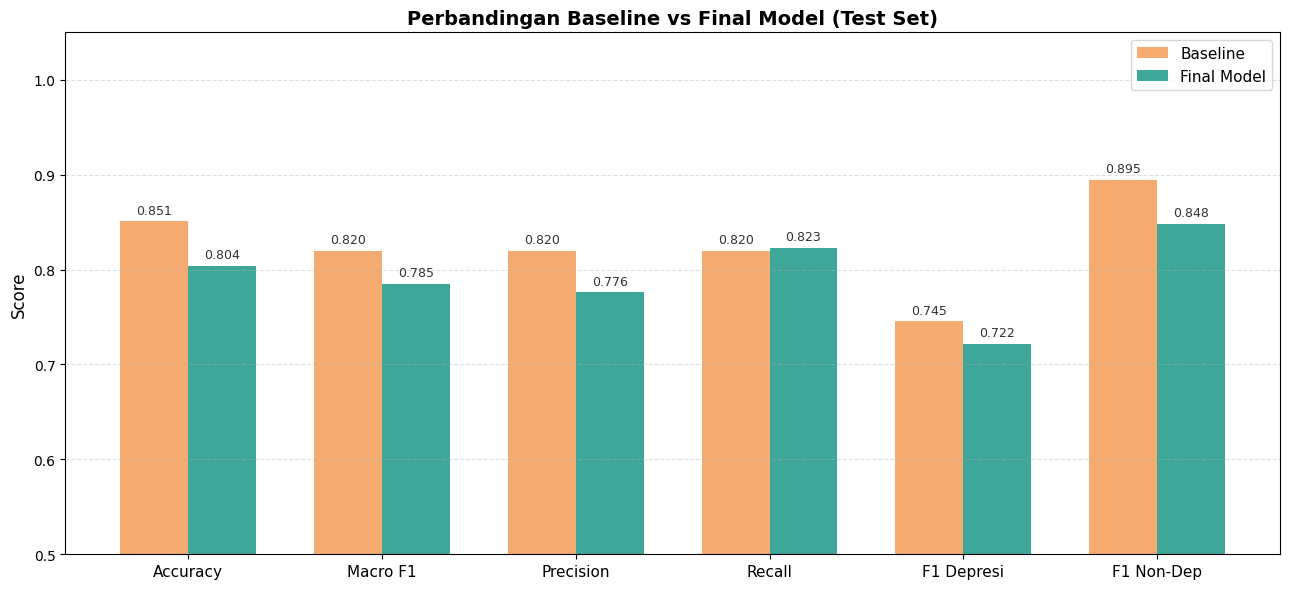

Grafik disimpan ke Google Drive.


In [18]:
# ── Bar Chart: Baseline vs Final semua metrik ──
metric_labels = ['Accuracy', 'Macro F1', 'Precision', 'Recall', 'F1 Depresi', 'F1 Non-Dep']
base_vals  = [
    base_test_results.get('eval_accuracy', 0),
    base_test_results.get('eval_f1_macro', 0),
    base_test_results.get('eval_precision_macro', 0),
    base_test_results.get('eval_recall_macro', 0),
    base_test_results.get('eval_f1_depresi', 0),
    base_test_results.get('eval_f1_non_depresi', 0),
]
final_vals = [
    eval_results.get('eval_accuracy', 0),
    eval_results.get('eval_f1_macro', 0),
    eval_results.get('eval_precision_macro', 0),
    eval_results.get('eval_recall_macro', 0),
    eval_results.get('eval_f1_depresi', 0),
    eval_results.get('eval_f1_non_depresi', 0),
]

x   = np.arange(len(metric_labels))
w   = 0.35
fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - w/2, base_vals,  w, label='Baseline',    color='#f4a261', alpha=0.9)
bars2 = ax.bar(x + w/2, final_vals, w, label='Final Model', color='#2a9d8f', alpha=0.9)

ax.set_ylim(0.5, 1.05)
ax.set_xticks(x); ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Perbandingan Baseline vs Final Model (Test Set)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4, axis='y')

for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#333')
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#333')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EmosiKu_Model/baseline_vs_final.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan ke Google Drive.')


In [19]:
# ── Tabel Perbandingan Train vs Test ──
metrics_keys = ['accuracy', 'f1_macro', 'precision_macro', 'recall_macro', 'f1_depresi', 'f1_non_depresi']
labels_map   = {
    'accuracy'       : 'Accuracy',
    'f1_macro'       : 'Macro F1',
    'precision_macro': 'Macro Precision',
    'recall_macro'   : 'Macro Recall',
    'f1_depresi'     : 'F1 Depresi',
    'f1_non_depresi' : 'F1 Non-Depresi',
}

rows = []
for k in metrics_keys:
    train_val = train_results.get(f'eval_{k}', None)
    test_val  = eval_results.get(f'eval_{k}', None)
    gap       = (train_val - test_val) if (train_val and test_val) else None
    rows.append({
        'Metrik'      : labels_map[k],
        'Train'       : f'{train_val:.4f}' if train_val else '-',
        'Test'        : f'{test_val:.4f}'  if test_val  else '-',
        'Gap (↑=overfit)': f'{gap:+.4f}'  if gap is not None else '-',
    })

compare_df = pd.DataFrame(rows)
print('=' * 65)
print('  PERBANDINGAN AKURASI TRAIN vs TEST SET')
print('=' * 65)
display(compare_df)

# ── Diagnosis overfitting otomatis ──
acc_gap = train_results.get('eval_accuracy', 0) - eval_results.get('eval_accuracy', 0)
f1_gap  = train_results.get('eval_f1_macro', 0) - eval_results.get('eval_f1_macro', 0)

print('\n📊 DIAGNOSIS OVERFITTING:')
print(f'   Gap Accuracy (Train-Test) : {acc_gap:+.4f}')
print(f'   Gap Macro F1 (Train-Test) : {f1_gap:+.4f}')

if acc_gap > 0.10:
    print('   ⚠️  OVERFITTING — gap > 10%, model terlalu hafal data train')
elif acc_gap > 0.05:
    print('   ⚡ MILD OVERFITTING — gap 5-10%, masih dalam batas wajar untuk BERT')
elif acc_gap < -0.02:
    print('   ⚠️  UNDERFITTING — test lebih tinggi dari train, model belum konvergen')
else:
    print('   ✅ GOOD FIT — gap kecil, model generalisasi dengan baik')


  PERBANDINGAN AKURASI TRAIN vs TEST SET


,Metrik,Train,Test,Gap (↑=overfit)
0,Accuracy,0.9390,0.8036,+0.1354
1,Macro F1,0.9390,0.7850,+0.1540
2,Macro Precision,0.9405,0.7759,+0.1646
3,Macro Recall,0.9390,0.8230,+0.1161
4,F1 Depresi,0.9407,0.7216,+0.2191
5,F1 Non-Depresi,0.9372,0.8483,+0.0889



📊 DIAGNOSIS OVERFITTING:
   Gap Accuracy (Train-Test) : +0.1354
   Gap Macro F1 (Train-Test) : +0.1540
   ⚠️  OVERFITTING — gap > 10%, model terlalu hafal data train


In [20]:
model_save_path = '/content/drive/MyDrive/EmosiKu_Model/best_model'
os.makedirs(model_save_path, exist_ok=True)
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)
print(f"Model berhasil disimpan secara permanen di {model_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model berhasil disimpan secara permanen di /content/drive/MyDrive/EmosiKu_Model/best_model


## 8. Grafik Monitoring Training (Final Model)


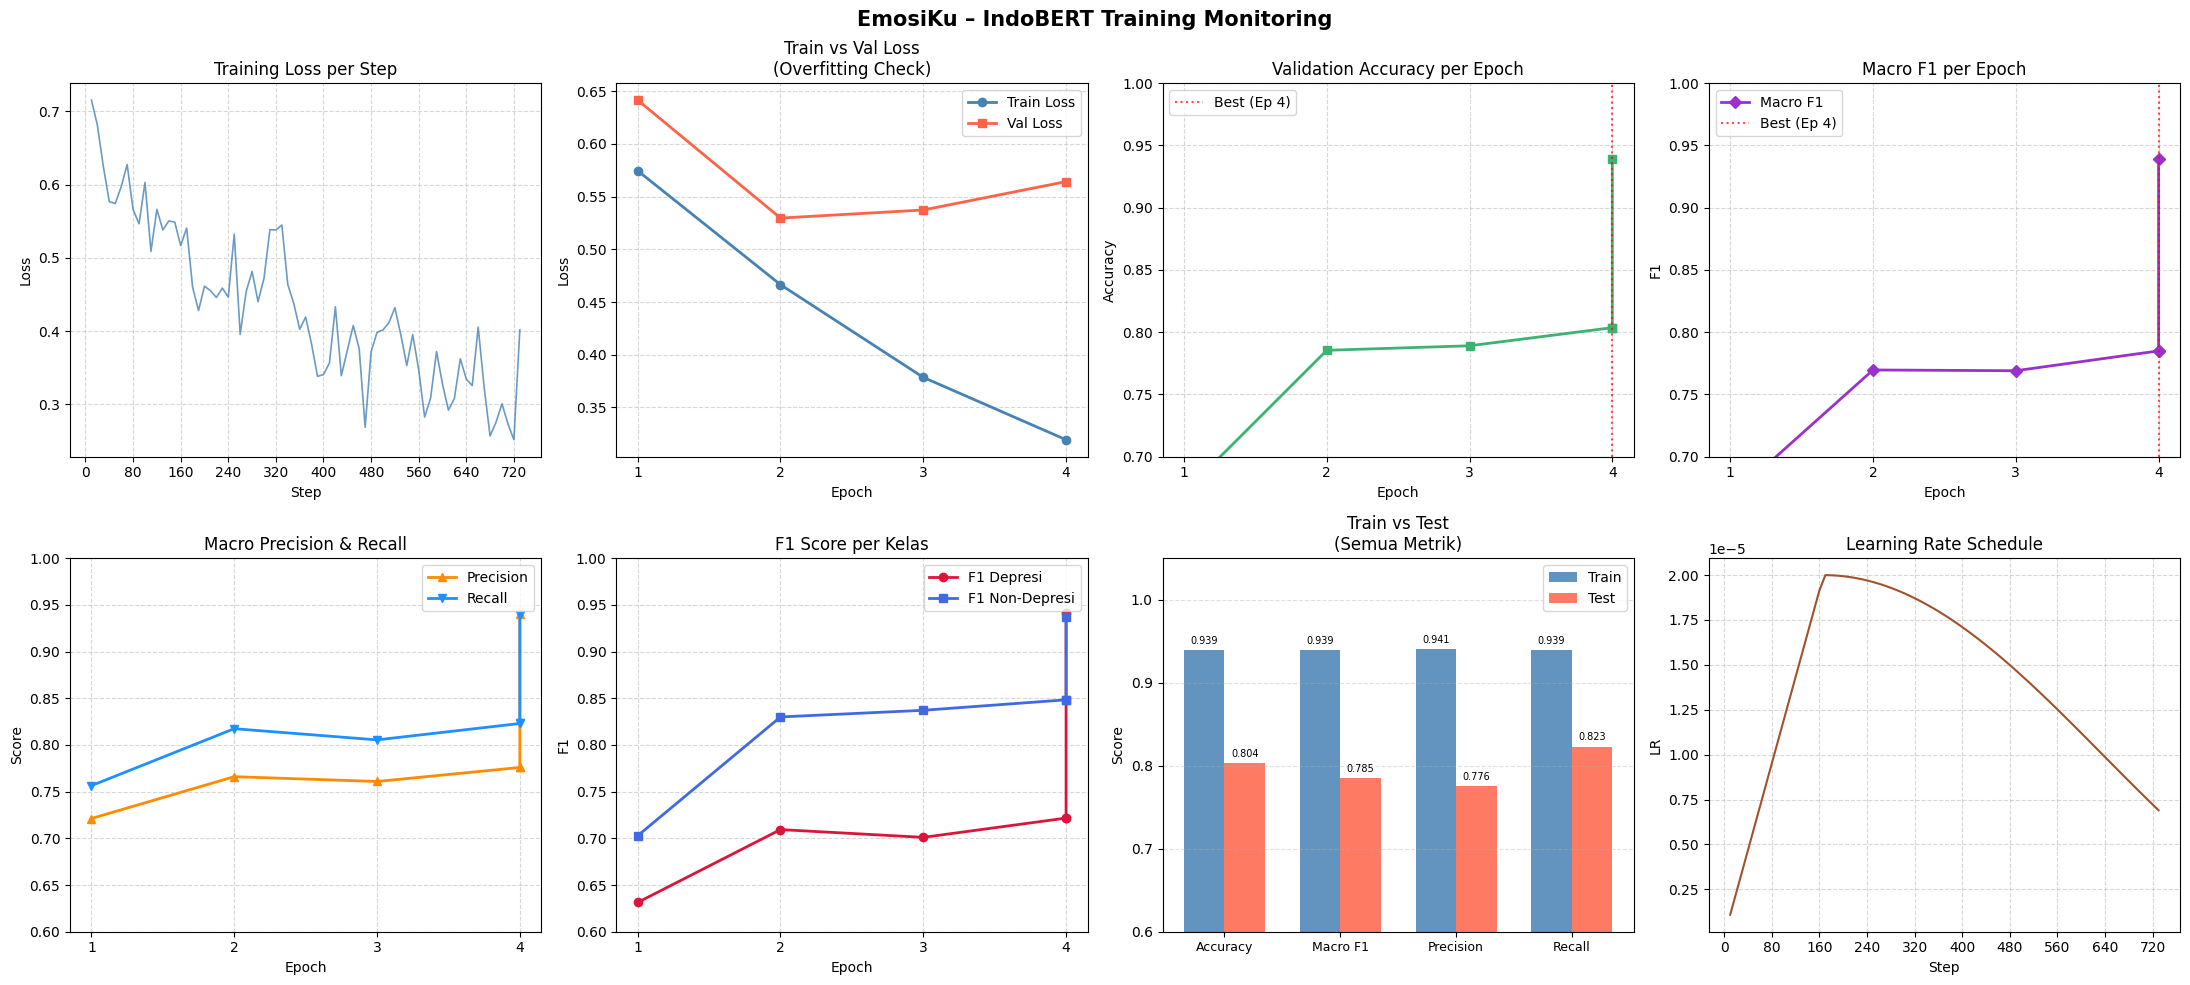

Grafik disimpan ke: /content/drive/MyDrive/EmosiKu_Model/training_monitoring_final.png


In [21]:
log_history = trainer.state.log_history

train_logs = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs  = [x for x in log_history if 'eval_loss' in x]

train_steps  = [x['step'] for x in train_logs]
train_losses = [x['loss'] for x in train_logs]

eval_epochs     = [x['epoch']                    for x in eval_logs]
eval_losses     = [x['eval_loss']                for x in eval_logs]
eval_accuracy   = [x.get('eval_accuracy')        for x in eval_logs]
eval_f1_macro   = [x.get('eval_f1_macro')        for x in eval_logs]
eval_precision  = [x.get('eval_precision_macro') for x in eval_logs]
eval_recall     = [x.get('eval_recall_macro')    for x in eval_logs]
eval_f1_dep     = [x.get('eval_f1_depresi')      for x in eval_logs]
eval_f1_nondep  = [x.get('eval_f1_non_depresi')  for x in eval_logs]

lr_logs   = [x for x in log_history if 'learning_rate' in x]
lr_steps  = [x['step']          for x in lr_logs]
lr_values = [x['learning_rate'] for x in lr_logs]

# Rata-rata train loss per epoch
steps_per_epoch = len(train_dataset) // training_args.per_device_train_batch_size + 1
epoch_train_loss = {}
for x in train_logs:
    ep = int(np.ceil(x['step'] / steps_per_epoch))
    epoch_train_loss.setdefault(ep, []).append(x['loss'])
ep_keys         = sorted(epoch_train_loss)
avg_train_losses = [np.mean(epoch_train_loss[e]) for e in ep_keys]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('EmosiKu – IndoBERT Training Monitoring', fontsize=15, fontweight='bold')

# [0,0] Training Loss per Step
axes[0,0].plot(train_steps, train_losses, color='steelblue', linewidth=1.2, alpha=0.8)
axes[0,0].set_title('Training Loss per Step')
axes[0,0].set_xlabel('Step'); axes[0,0].set_ylabel('Loss')
axes[0,0].grid(True, linestyle='--', alpha=0.5)

# [0,1] Train vs Eval Loss per Epoch — overfitting check
axes[0,1].plot(ep_keys, avg_train_losses, color='steelblue', marker='o', linewidth=2, label='Train Loss')
axes[0,1].plot(eval_epochs[:len(ep_keys)], eval_losses[:len(ep_keys)], color='tomato', marker='s', linewidth=2, label='Val Loss')
axes[0,1].set_title('Train vs Val Loss\n(Overfitting Check)')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Loss')
axes[0,1].legend(); axes[0,1].grid(True, linestyle='--', alpha=0.5)

# [0,2] Validation Accuracy per Epoch
axes[0,2].plot(eval_epochs, eval_accuracy, color='mediumseagreen', marker='s', linewidth=2)
# Tandai best epoch
best_idx = eval_f1_macro.index(max(eval_f1_macro))
axes[0,2].axvline(x=eval_epochs[best_idx], color='red', linestyle=':', alpha=0.7, label=f'Best (Ep {eval_epochs[best_idx]:.0f})')
axes[0,2].set_ylim(0.7, 1.0)
axes[0,2].set_title('Validation Accuracy per Epoch')
axes[0,2].set_xlabel('Epoch'); axes[0,2].set_ylabel('Accuracy')
axes[0,2].legend(); axes[0,2].grid(True, linestyle='--', alpha=0.5)

# [0,3] Macro F1 per Epoch
axes[0,3].plot(eval_epochs, eval_f1_macro, color='darkorchid', marker='D', linewidth=2, label='Macro F1')
axes[0,3].axvline(x=eval_epochs[best_idx], color='red', linestyle=':', alpha=0.7, label=f'Best (Ep {eval_epochs[best_idx]:.0f})')
axes[0,3].set_ylim(0.7, 1.0)
axes[0,3].set_title('Macro F1 per Epoch')
axes[0,3].set_xlabel('Epoch'); axes[0,3].set_ylabel('F1')
axes[0,3].legend(); axes[0,3].grid(True, linestyle='--', alpha=0.5)

# [1,0] Macro Precision & Recall
axes[1,0].plot(eval_epochs, eval_precision, color='darkorange', marker='^', linewidth=2, label='Precision')
axes[1,0].plot(eval_epochs, eval_recall,    color='dodgerblue', marker='v', linewidth=2, label='Recall')
axes[1,0].set_ylim(0.6, 1.0)
axes[1,0].set_title('Macro Precision & Recall')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Score')
axes[1,0].legend(); axes[1,0].grid(True, linestyle='--', alpha=0.5)

# [1,1] F1 per Kelas
axes[1,1].plot(eval_epochs, eval_f1_dep,    color='crimson',   marker='o', linewidth=2, label='F1 Depresi')
axes[1,1].plot(eval_epochs, eval_f1_nondep, color='royalblue', marker='s', linewidth=2, label='F1 Non-Depresi')
axes[1,1].set_ylim(0.6, 1.0)
axes[1,1].set_title('F1 Score per Kelas')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('F1')
axes[1,1].legend(); axes[1,1].grid(True, linestyle='--', alpha=0.5)

# [1,2] Bar chart Train vs Test semua metrik
bar_metrics = ['Accuracy', 'Macro F1', 'Precision', 'Recall']
train_vals  = [
    train_results.get('eval_accuracy', 0),
    train_results.get('eval_f1_macro', 0),
    train_results.get('eval_precision_macro', 0),
    train_results.get('eval_recall_macro', 0),
]
test_vals   = [
    eval_results.get('eval_accuracy', 0),
    eval_results.get('eval_f1_macro', 0),
    eval_results.get('eval_precision_macro', 0),
    eval_results.get('eval_recall_macro', 0),
]
x_bar = np.arange(len(bar_metrics))
w     = 0.35
bars1 = axes[1,2].bar(x_bar - w/2, train_vals, w, label='Train', color='steelblue', alpha=0.85)
bars2 = axes[1,2].bar(x_bar + w/2, test_vals,  w, label='Test',  color='tomato',    alpha=0.85)
axes[1,2].set_ylim(0.6, 1.05)
axes[1,2].set_xticks(x_bar); axes[1,2].set_xticklabels(bar_metrics, fontsize=9)
axes[1,2].set_title('Train vs Test\n(Semua Metrik)')
axes[1,2].set_ylabel('Score')
axes[1,2].legend()
axes[1,2].grid(True, linestyle='--', alpha=0.4, axis='y')
for bar in bars1: axes[1,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
for bar in bars2: axes[1,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

# [1,3] Learning Rate Schedule
if lr_steps:
    axes[1,3].plot(lr_steps, lr_values, color='sienna', linewidth=1.5)
axes[1,3].set_title('Learning Rate Schedule')
axes[1,3].set_xlabel('Step'); axes[1,3].set_ylabel('LR')
axes[1,3].grid(True, linestyle='--', alpha=0.5)

for ax in axes.flat:
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
save_path = '/content/drive/MyDrive/EmosiKu_Model/training_monitoring_final.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Grafik disimpan ke: {save_path}')


In [22]:
summary = pd.DataFrame({
    'Epoch'          : eval_epochs,
    'Eval Loss'      : [round(v, 4) for v in eval_losses],
    'Accuracy'       : [round(v, 4) if v else None for v in eval_accuracy],
    'Macro F1'       : [round(v, 4) if v else None for v in eval_f1_macro],
    'Macro Precision': [round(v, 4) if v else None for v in eval_precision],
    'Macro Recall'   : [round(v, 4) if v else None for v in eval_recall],
    'F1 Depresi'     : [round(v, 4) if v else None for v in eval_f1_dep],
    'F1 Non-Depresi' : [round(v, 4) if v else None for v in eval_f1_nondep],
})

# Hapus baris duplikat epoch 4.0 terakhir (dari evaluate() terakhir)
summary = summary.drop_duplicates(subset='Epoch').reset_index(drop=True)

best_row = summary.loc[summary['Macro F1'].idxmax()]
print('=' * 75)
print('  RINGKASAN METRIK PER EPOCH (TEST SET / VALIDATION)')
print('=' * 75)
display(summary.style.highlight_max(subset=['Accuracy','Macro F1','F1 Depresi','F1 Non-Depresi'], color='lightgreen')
               .highlight_min(subset=['Eval Loss'], color='lightgreen')
               .format(precision=4))
print(f"\n✅ Best Epoch  : {best_row['Epoch']:.0f}")
print(f"   Accuracy    : {best_row['Accuracy']:.4f}  ({best_row['Accuracy']*100:.2f}%)")
print(f"   Macro F1    : {best_row['Macro F1']:.4f}  ({best_row['Macro F1']*100:.2f}%)")
print(f"   F1 Depresi  : {best_row['F1 Depresi']:.4f}  ({best_row['F1 Depresi']*100:.2f}%)")
print(f"   F1 Non-Dep  : {best_row['F1 Non-Depresi']:.4f}  ({best_row['F1 Non-Depresi']*100:.2f}%)")


  RINGKASAN METRIK PER EPOCH (TEST SET / VALIDATION)


,Epoch,Eval Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,F1 Depresi,F1 Non-Depresi
0,1.0000,0.6416,0.6709,0.6671,0.7212,0.7564,0.6314,0.7028
1,2.0000,0.5297,0.7855,0.7697,0.7660,0.8174,0.7094,0.8300
2,3.0000,0.5373,0.7891,0.7691,0.7609,0.8054,0.7010,0.8371
3,4.0000,0.5643,0.8036,0.7850,0.7759,0.8230,0.7216,0.8483



✅ Best Epoch  : 4
   Accuracy    : 0.8036  (80.36%)
   Macro F1    : 0.7850  (78.50%)
   F1 Depresi  : 0.7216  (72.16%)
   F1 Non-Dep  : 0.8483  (84.83%)


## 9. Confusion Matrix Final Model


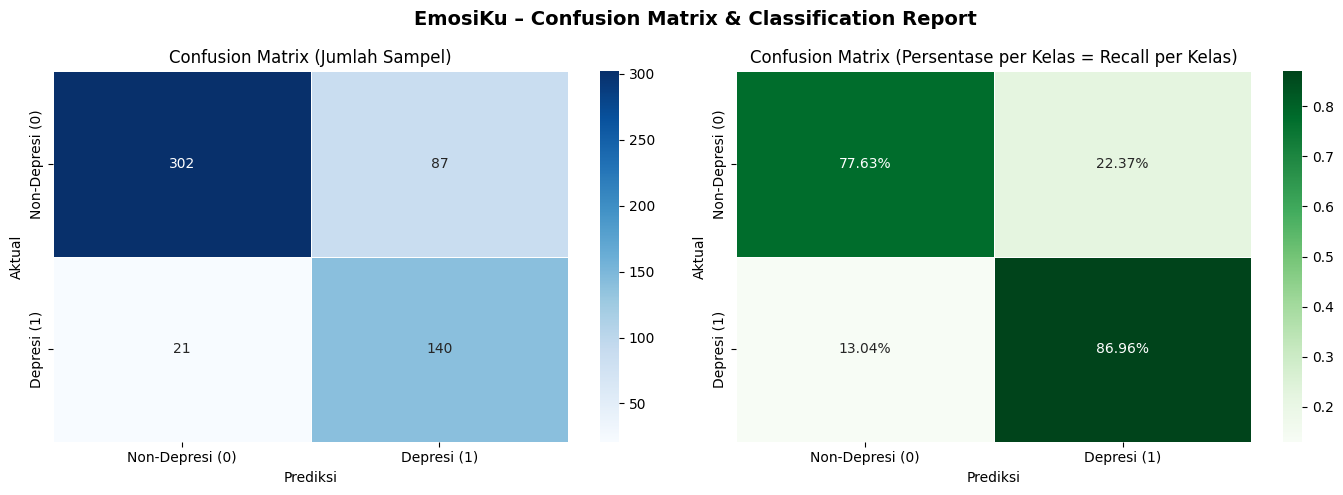


  CLASSIFICATION REPORT (TEST SET)
                 precision    recall  f1-score   support

Non-Depresi (0)     0.9350    0.7763    0.8483       389
    Depresi (1)     0.6167    0.8696    0.7216       161

       accuracy                         0.8036       550
      macro avg     0.7759    0.8230    0.7850       550
   weighted avg     0.8418    0.8036    0.8112       550


  AKURASI PER KELAS
  Accuracy Non-Depresi : 302/389 = 0.7763 (77.63%)
  Accuracy Depresi     : 140/161 = 0.8696 (86.96%)
  Accuracy Keseluruhan : 442/550 = 0.8036 (80.36%)

  DETAIL CONFUSION MATRIX
  TN (Non-Dep → Non-Dep) :  302  ✅ Benar
  FP (Non-Dep → Depresi) :   87  ❌ Salah (False Alarm)
  FN (Depresi → Non-Dep) :   21  ❌ Salah (Missed Case)
  TP (Depresi → Depresi) :  140  ✅ Benar

  → 21 kasus Depresi yang terlewat (FN) lebih berbahaya untuk konteks kesehatan mental
  → Recall Depresi 87.0% artinya model berhasil mendeteksi 140 dari 161 kasus depresi

Grafik disimpan ke Google Drive.


In [23]:
from sklearn.metrics import confusion_matrix, classification_report

predictions_output = trainer.predict(test_dataset)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

class_names = ['Non-Depresi (0)', 'Depresi (1)']
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EmosiKu – Confusion Matrix & Classification Report', fontsize=14, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix (Jumlah Sampel)')
axes[0].set_xlabel('Prediksi'); axes[0].set_ylabel('Aktual')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Confusion Matrix (Persentase per Kelas = Recall per Kelas)')
axes[1].set_xlabel('Prediksi'); axes[1].set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EmosiKu_Model/confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Classification Report lengkap ──
print('\n' + '=' * 60)
print('  CLASSIFICATION REPORT (TEST SET)')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# ── Akurasi per kelas (recall diagonal) ──
tn, fp, fn, tp = cm.ravel()
acc_non_dep = tn / (tn + fp)
acc_depresi = tp / (tp + fn)
acc_total   = (tn + tp) / (tn + fp + fn + tp)

print('\n' + '=' * 60)
print('  AKURASI PER KELAS')
print('=' * 60)
print(f'  Accuracy Non-Depresi : {tn}/{tn+fp} = {acc_non_dep:.4f} ({acc_non_dep*100:.2f}%)')
print(f'  Accuracy Depresi     : {tp}/{tp+fn} = {acc_depresi:.4f} ({acc_depresi*100:.2f}%)')
print(f'  Accuracy Keseluruhan : {tn+tp}/{tn+fp+fn+tp} = {acc_total:.4f} ({acc_total*100:.2f}%)')

print('\n' + '=' * 60)
print('  DETAIL CONFUSION MATRIX')
print('=' * 60)
print(f'  TN (Non-Dep → Non-Dep) : {tn:>4}  ✅ Benar')
print(f'  FP (Non-Dep → Depresi) : {fp:>4}  ❌ Salah (False Alarm)')
print(f'  FN (Depresi → Non-Dep) : {fn:>4}  ❌ Salah (Missed Case)')
print(f'  TP (Depresi → Depresi) : {tp:>4}  ✅ Benar')
print(f'\n  → {fn} kasus Depresi yang terlewat (FN) lebih berbahaya untuk konteks kesehatan mental')
print(f'  → Recall Depresi {acc_depresi*100:.1f}% artinya model berhasil mendeteksi {tp} dari {tp+fn} kasus depresi')
print('\nGrafik disimpan ke Google Drive.')
